# CreditWise — Loan Approval Prediction System

### Objective
Build a clean, reproducible machine-learning pipeline that predicts whether a loan application will be approved.

This notebook is organized as a complete ML workflow:

**Data Understanding → Data Cleaning → EDA → Feature Engineering → Leakage-Safe Preprocessing → Model Comparison → Cross-Validation → Hyperparameter Tuning → Evaluation → Feature Importance → Model Saving → Example Prediction**

> **Important:** The original dataset contains 1,000 rows, but 50 rows have a missing `Loan_Approved` target. Those rows are excluded from supervised training rather than imputing the target, because the target is the value we are trying to predict.


## 1. Import Required Libraries

We use:
- **Pandas / NumPy** for data manipulation
- **Matplotlib / Seaborn** for visualization
- **Scikit-learn** for preprocessing, modeling, tuning and evaluation
- **Joblib** to save the final trained model


In [1]:
# Core data-science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: data splitting, preprocessing, models and evaluation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# Save the trained pipeline
import joblib

# Make plots easier to read
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42


## 2. Load the Dataset

In [2]:
# Load the original dataset.
# Keep the CSV file in the same directory as this notebook.
df = pd.read_csv("loan_approval_data.csv")

print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset shape: (1000, 20)


,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


## 3. Understand the Data

The dataset contains applicant financial, employment and demographic information.

We first inspect:
- data types
- missing values
- target distribution
- unique categorical values

This helps us decide how each feature should be handled.


In [3]:
# Basic structure and data types
df.info()

print("\nMissing values by column:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nTarget distribution including missing targets:")
display(df["Loan_Approved"].value_counts(dropna=False))

print("\nCategorical feature values:")
for col in df.select_dtypes(include="object").columns:
    print(f"{col}: {df[col].dropna().unique()}")


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    str    
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    str    
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    str    
 15  Property_Area       950 non-null    str    
 16  Education_Level   

Applicant_ID          50
Applicant_Income      50
Employer_Category     50
Gender                50
Education_Level       50
Property_Area         50
Loan_Purpose          50
Loan_Term             50
Loan_Amount           50
Collateral_Value      50
Savings               50
DTI_Ratio             50
Existing_Loans        50
Credit_Score          50
Dependents            50
Marital_Status        50
Age                   50
Employment_Status     50
Coapplicant_Income    50
Loan_Approved         50
dtype: int64


Target distribution including missing targets:


Loan_Approved
No     652
Yes    298
NaN     50
Name: count, dtype: int64


Categorical feature values:
Employment_Status: <ArrowStringArray>
['Salaried', 'Self-employed', 'Contract', 'Unemployed']
Length: 4, dtype: str
Marital_Status: <ArrowStringArray>
['Married', 'Single']
Length: 2, dtype: str
Loan_Purpose: <ArrowStringArray>
['Personal', 'Car', 'Business', 'Home', 'Education']
Length: 5, dtype: str
Property_Area: <ArrowStringArray>
['Urban', 'Semiurban', 'Rural']
Length: 3, dtype: str
Education_Level: <ArrowStringArray>
['Not Graduate', 'Graduate']
Length: 2, dtype: str
Gender: <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
Employer_Category: <ArrowStringArray>
['Private', 'Government', 'Unemployed', 'MNC', 'Business']
Length: 5, dtype: str
Loan_Approved: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


/var/folders/wh/4tzcmnpx5t3cbrnd1n1n14g80000gn/T/ipykernel_1506/1701723130.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


## 4. Handle Missing Target Values Correctly

There are 50 applications where `Loan_Approved` is missing.

We **must not** fill these target values using the most-frequent class. Doing that would create artificial labels and could bias the model.

Instead:
1. Remove rows with an unknown target.
2. Keep missing values in input features for the preprocessing pipeline to handle later.


In [4]:
# Remove rows where the value we want to predict is unknown.
df_model = df.dropna(subset=["Loan_Approved"]).copy()

print(f"Original rows: {len(df):,}")
print(f"Rows available for supervised learning: {len(df_model):,}")
print(f"Rows excluded because target was missing: {len(df) - len(df_model):,}")

# Convert the target from Yes/No to binary labels.
df_model["Loan_Approved"] = df_model["Loan_Approved"].map({
    "No": 0,
    "Yes": 1
})

print("\nTarget distribution after cleaning:")
display(df_model["Loan_Approved"].value_counts())


Original rows: 1,000
Rows available for supervised learning: 950
Rows excluded because target was missing: 50

Target distribution after cleaning:


Loan_Approved
0    652
1    298
Name: count, dtype: int64

## 5. Exploratory Data Analysis

### Target Balance

Understanding the target distribution is important because accuracy can be misleading when classes are imbalanced.


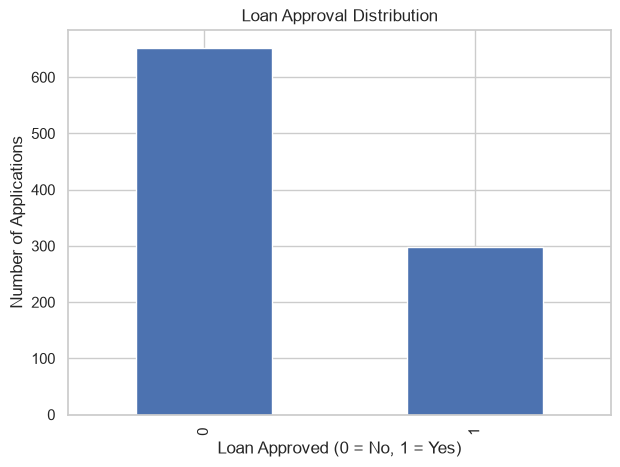

In [5]:
# Visualize the number of approved and rejected applications.
plt.figure(figsize=(7, 5))
df_model["Loan_Approved"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(7, 5)
)
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approved (0 = No, 1 = Yes)")
plt.ylabel("Number of Applications")
plt.show()


### Important Numeric Features

The original notebook found meaningful relationships between loan approval and features such as `Credit_Score`, `DTI_Ratio`, `Applicant_Income`, `Loan_Amount` and `Loan_Term`.

We visualize these relationships before modeling.


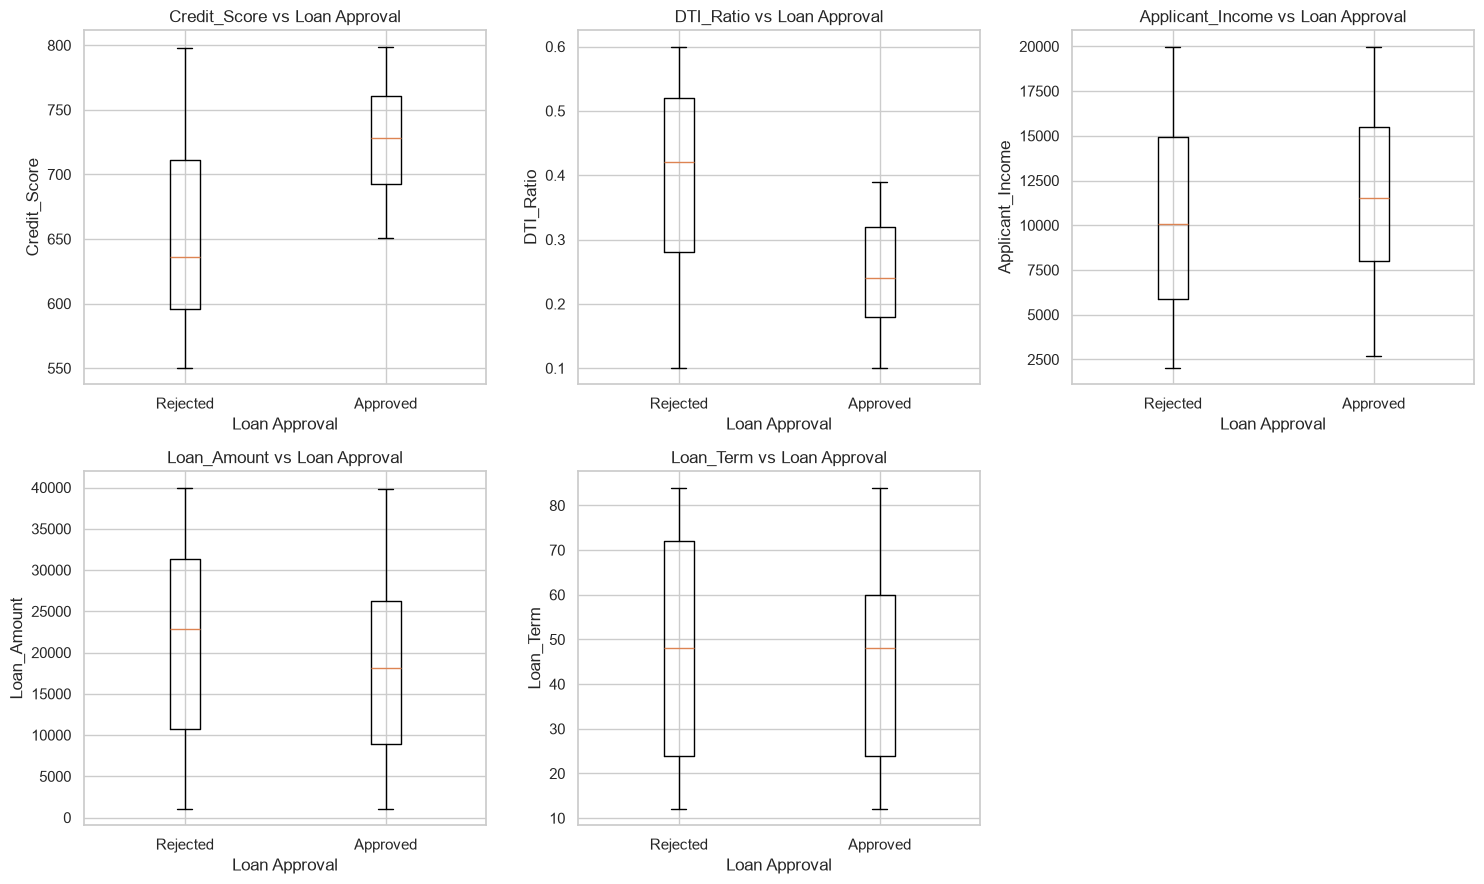

In [6]:
# Selected numeric features for visual comparison.
important_numeric = [
    "Credit_Score",
    "DTI_Ratio",
    "Applicant_Income",
    "Loan_Amount",
    "Loan_Term"
]

# Draw one boxplot for each selected numeric feature.
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, col in zip(axes, important_numeric):
    approved = df_model.loc[df_model["Loan_Approved"] == 1, col].dropna()
    rejected = df_model.loc[df_model["Loan_Approved"] == 0, col].dropna()

    ax.boxplot(
        [rejected, approved],
        tick_labels=["Rejected", "Approved"]
    )
    ax.set_title(f"{col} vs Loan Approval")
    ax.set_xlabel("Loan Approval")
    ax.set_ylabel(col)

axes[-1].axis("off")
plt.tight_layout()
plt.show()


## 6. Remove Identifier Columns

`Applicant_ID` identifies a record but does not represent a meaningful characteristic of creditworthiness.

Including an ID can introduce noise or accidental patterns, so it is excluded from the feature set.


In [7]:
# Remove the identifier from the modeling dataset.
df_model = df_model.drop(columns=["Applicant_ID"])

print("Remaining columns:")
print(df_model.columns.tolist())


Remaining columns:
['Applicant_Income', 'Coapplicant_Income', 'Employment_Status', 'Age', 'Marital_Status', 'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved']


## 7. Feature Engineering

We create a few financially meaningful features.

- **Total_Income:** applicant + coapplicant income
- **Loan_to_Income:** requested loan relative to total income
- **Collateral_to_Loan:** collateral value relative to requested loan
- **DTI_Squared:** captures possible nonlinear DTI effects
- **Credit_Score_Squared:** captures possible nonlinear credit-score effects

These transformations are deterministic: they do not learn parameters from the test set, so they can safely be created before splitting.


In [8]:
# Total household/applicant income available to support the loan.
df_model["Total_Income"] = (
    df_model["Applicant_Income"] + df_model["Coapplicant_Income"]
)

# How large the requested loan is relative to total income.
df_model["Loan_to_Income"] = (
    df_model["Loan_Amount"] / (df_model["Total_Income"] + 1)
)

# How much collateral exists relative to the requested loan amount.
df_model["Collateral_to_Loan"] = (
    df_model["Collateral_Value"] / (df_model["Loan_Amount"] + 1)
)

# Squared terms allow linear models to represent simple nonlinear effects.
df_model["DTI_Squared"] = df_model["DTI_Ratio"] ** 2
df_model["Credit_Score_Squared"] = df_model["Credit_Score"] ** 2

display(df_model.head())


,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,...,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved,Total_Income,Loan_to_Income,Collateral_to_Loan,DTI_Squared,Credit_Score_Squared
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,...,Urban,Not Graduate,Female,Private,0,19182.0,0.866340,2.745969,0.2809,405769.0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,...,Semiurban,Graduate,NaN,Private,0,5539.0,6.983213,1.273573,0.0900,385641.0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,...,Urban,NaN,Female,Government,1,9496.0,2.942298,0.247209,0.0400,454276.0
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,...,Rural,Graduate,Female,Government,0,22137.0,1.256618,0.389792,0.0961,335241.0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,...,NaN,Graduate,Male,Private,1,17507.0,0.727724,2.953147,0.0841,519841.0


## 8. Separate Features and Target

The target is `Loan_Approved`.

We also use a **stratified** train/test split so that the approval/rejection ratio is approximately preserved in both sets.


In [9]:
# X contains input features; y contains the value we want to predict.
X = df_model.drop(columns=["Loan_Approved"])
y = df_model["Loan_Approved"]

# Stratification keeps the class proportions similar in train and test data.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training samples: {len(X_train):,}")
print(f"Testing samples:  {len(X_test):,}")


Training samples: 760
Testing samples:  190


## 9. Leakage-Safe Preprocessing Pipeline

The original notebook performed imputation and encoding before the train/test split. That can cause **data leakage**, because information from the test set can influence preprocessing.

Here, all learned preprocessing is placed inside a `Pipeline`:

**Training data → Imputation → Encoding → Scaling → Model**

The preprocessing is fitted only on the training folds during validation/tuning.

### Numeric features
- Median imputation
- Standard scaling

### Categorical features
- Most-frequent imputation
- One-hot encoding
- Unknown categories are safely ignored


In [10]:
# Identify numeric and categorical columns from the training data.
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

# Numeric preprocessing:
# 1. Fill missing numeric values with the median.
# 2. Scale values so distance/linear-based models work better.
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing:
# 1. Fill missing categories with the most common value.
# 2. Convert categories into binary indicator columns.
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])

# Apply the correct preprocessing to each type of feature.
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)


Numeric features:
['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Total_Income', 'Loan_to_Income', 'Collateral_to_Loan', 'DTI_Squared', 'Credit_Score_Squared']

Categorical features:
['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender', 'Employer_Category']


## 10. Baseline Model Comparison

We compare three different classification approaches:

1. **Logistic Regression** — strong and interpretable baseline
2. **Random Forest** — captures nonlinear relationships and feature interactions
3. **Gradient Boosting** — sequentially improves weak learners to model complex patterns

We evaluate them using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

For this problem, **F1-score and ROC-AUC** are especially useful alongside accuracy because we care about both types of classification errors.


In [11]:
# Define baseline models.
baseline_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

results = []

for name, model in baseline_models.items():

    # Put preprocessing and the model into one reproducible pipeline.
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train only on the training set.
    pipeline.fit(X_train, y_train)

    # Generate predictions and probabilities on unseen test data.
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

baseline_results = pd.DataFrame(results).sort_values(
    "F1", ascending=False
).reset_index(drop=True)

display(baseline_results.round(4))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Gradient Boosting,0.9579,0.8939,0.9833,0.9365,0.9863
1,Random Forest,0.9474,0.8788,0.9667,0.9206,0.9804
2,Logistic Regression,0.8789,0.7681,0.8833,0.8217,0.9500


## 11. 5-Fold Stratified Cross-Validation

A single train/test split gives only one estimate of model performance.

We therefore use **5-fold stratified cross-validation** on the training data.

This provides a more reliable estimate while keeping the final test set untouched for the final evaluation.


In [12]:
# StratifiedKFold preserves the class ratio in every fold.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = []

for name, model in baseline_models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1",
            "roc_auc": "roc_auc"
        },
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    "CV F1", ascending=False
).reset_index(drop=True)

display(cv_results_df.round(4))


,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,Gradient Boosting,0.9592,0.9125,0.9621,0.9366,0.9884
1,Random Forest,0.9566,0.8932,0.9790,0.9339,0.9831
2,Logistic Regression,0.8803,0.7610,0.8991,0.8241,0.9454


## 12. Hyperparameter Tuning

Instead of accepting the default Gradient Boosting settings, we search for a better configuration.

`RandomizedSearchCV` tests multiple combinations using 5-fold cross-validation.

The search is performed on the **training data only**. The final test set remains unseen until the end.


In [13]:
# Build the Gradient Boosting pipeline.
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

# Hyperparameters that control model complexity and learning behaviour.
param_distributions = {
    "model__n_estimators": [100, 150, 200, 300],
    "model__learning_rate": [0.02, 0.05, 0.10, 0.15],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.8, 1.0]
}

# RandomizedSearchCV is faster than testing every possible combination.
gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False
)

# Tune only using training data.
gb_search.fit(X_train, y_train)

print("Best hyperparameters:")
print(gb_search.best_params_)

print(f"\nBest mean CV F1-score: {gb_search.best_score_:.4f}")


Best hyperparameters:
{'model__subsample': 1.0, 'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': 3, 'model__learning_rate': 0.1}

Best mean CV F1-score: 0.9366


## 13. Final Test-Set Evaluation

The tuned model is now evaluated on the test set that was never used during training or hyperparameter selection.

This gives us an honest estimate of generalization performance.


In [14]:
# The best estimator is already fitted by RandomizedSearchCV.
best_model = gb_search.best_estimator_

# Predict the test set.
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Calculate final metrics.
final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

print("Final Test-Set Performance")
for metric, value in final_metrics.items():
    print(f"{metric:10s}: {value:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Rejected", "Approved"]
))


Final Test-Set Performance
Accuracy  : 0.9421
Precision : 0.8769
Recall    : 0.9500
F1-score  : 0.9120
ROC-AUC   : 0.9854

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.98      0.94      0.96       130
    Approved       0.88      0.95      0.91        60

    accuracy                           0.94       190
   macro avg       0.93      0.94      0.93       190
weighted avg       0.94      0.94      0.94       190



## 14. Confusion Matrix

A confusion matrix shows how many applications were:
- correctly rejected
- incorrectly approved
- incorrectly rejected
- correctly approved

This is more informative than accuracy alone.


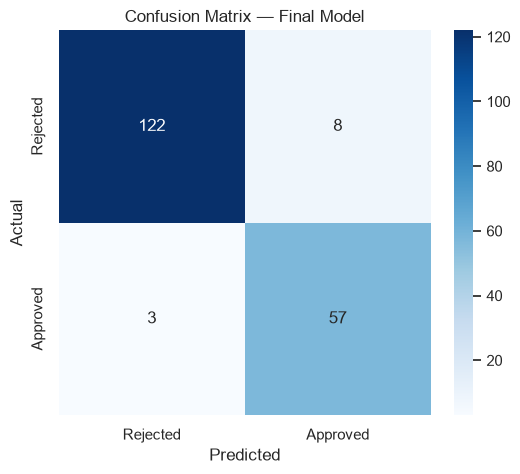

In [15]:
# Display the confusion matrix.
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)
plt.title("Confusion Matrix — Final Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 15. ROC-AUC Curve

ROC-AUC measures how well the model separates approved and rejected applications across different classification thresholds.


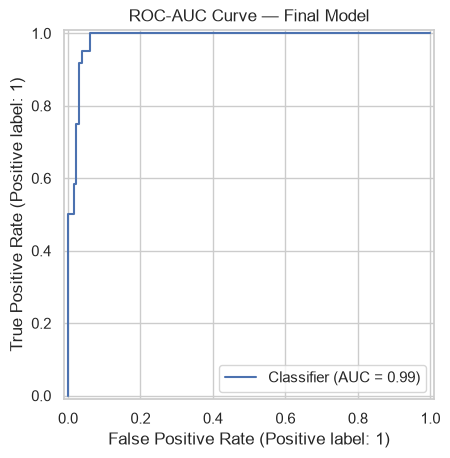

In [16]:
# Plot the ROC curve for the final tuned model.
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC-AUC Curve — Final Model")
plt.show()


## 16. Feature Importance

Gradient Boosting provides feature-importance scores.

Because categorical variables were one-hot encoded, we first retrieve the transformed feature names from the preprocessing pipeline and then match them with the model's importance scores.


Top 15 most important transformed features:


,Importance
numeric__DTI_Ratio,0.269146
numeric__DTI_Squared,0.205379
numeric__Credit_Score,0.190638
numeric__Credit_Score_Squared,0.128761
numeric__Applicant_Income,0.099741
numeric__Loan_to_Income,0.071933
numeric__Total_Income,0.011746
numeric__Savings,0.007644
numeric__Loan_Amount,0.006797
numeric__Age,0.002680


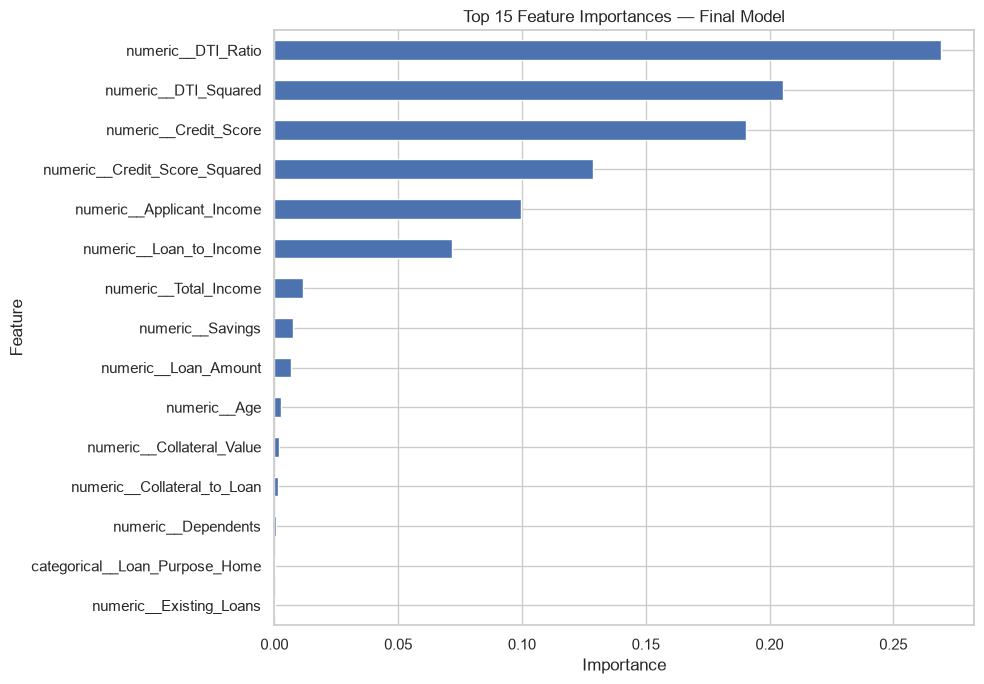

In [17]:
# Get the preprocessing step from the fitted pipeline.
fitted_preprocessor = best_model.named_steps["preprocessor"]
fitted_model = best_model.named_steps["model"]

# Retrieve feature names after imputation, scaling and one-hot encoding.
feature_names = fitted_preprocessor.get_feature_names_out()

# Match each transformed feature with its importance.
feature_importance = pd.Series(
    fitted_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print("Top 15 most important transformed features:")
display(feature_importance.head(15).to_frame("Importance"))

# Visualize the top 15 features.
plt.figure(figsize=(10, 7))
feature_importance.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances — Final Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 17. Compare Baseline vs Tuned Model

This final comparison makes the improvement from hyperparameter tuning easy to explain during an interview.


In [18]:
# Add the tuned model's test performance to the baseline comparison.
tuned_row = pd.DataFrame([{
    "Model": "Tuned Gradient Boosting",
    "Accuracy": final_metrics["Accuracy"],
    "Precision": final_metrics["Precision"],
    "Recall": final_metrics["Recall"],
    "F1": final_metrics["F1-score"],
    "ROC-AUC": final_metrics["ROC-AUC"]
}])

comparison = pd.concat(
    [baseline_results, tuned_row],
    ignore_index=True
).sort_values("F1", ascending=False).reset_index(drop=True)

display(comparison.round(4))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Gradient Boosting,0.9579,0.8939,0.9833,0.9365,0.9863
1,Random Forest,0.9474,0.8788,0.9667,0.9206,0.9804
2,Tuned Gradient Boosting,0.9421,0.8769,0.9500,0.9120,0.9854
3,Logistic Regression,0.8789,0.7681,0.8833,0.8217,0.9500


## 18. Save the Complete Model Pipeline

We save the **entire preprocessing + model pipeline**, not just the classifier.

This is important because a future application must perform exactly the same preprocessing used during training.

The saved file can later be loaded by a Flask/FastAPI backend.


In [19]:
# Save the complete fitted pipeline.
# It includes:
# - missing-value handling
# - one-hot encoding
# - scaling
# - tuned Gradient Boosting model
joblib.dump(best_model, "creditwise_loan_approval_pipeline.pkl")

print("Saved model: creditwise_loan_approval_pipeline.pkl")


Saved model: creditwise_loan_approval_pipeline.pkl


## 19. Example Real-Time Prediction

The following example shows how the saved pipeline can predict a new applicant.

The input uses the same original feature names expected by the model. The preprocessing pipeline handles the categorical variables automatically.


In [20]:
# Example applicant data.
sample_applicant = pd.DataFrame([{
    "Applicant_Income": 12000,
    "Coapplicant_Income": 4000,
    "Employment_Status": "Salaried",
    "Age": 32,
    "Marital_Status": "Single",
    "Dependents": 1,
    "Credit_Score": 720,
    "Existing_Loans": 1,
    "DTI_Ratio": 0.25,
    "Savings": 15000,
    "Collateral_Value": 40000,
    "Loan_Amount": 20000,
    "Loan_Term": 60,
    "Loan_Purpose": "Home",
    "Property_Area": "Urban",
    "Education_Level": "Graduate",
    "Gender": "Male",
    "Employer_Category": "Private"
}])

# Create the same engineered features used during training.
sample_applicant["Total_Income"] = (
    sample_applicant["Applicant_Income"] +
    sample_applicant["Coapplicant_Income"]
)

sample_applicant["Loan_to_Income"] = (
    sample_applicant["Loan_Amount"] /
    (sample_applicant["Total_Income"] + 1)
)

sample_applicant["Collateral_to_Loan"] = (
    sample_applicant["Collateral_Value"] /
    (sample_applicant["Loan_Amount"] + 1)
)

sample_applicant["DTI_Squared"] = sample_applicant["DTI_Ratio"] ** 2
sample_applicant["Credit_Score_Squared"] = sample_applicant["Credit_Score"] ** 2

# Generate prediction and probability.
prediction = best_model.predict(sample_applicant)[0]
probability = best_model.predict_proba(sample_applicant)[0, 1]

decision = "APPROVED" if prediction == 1 else "REJECTED"

print(f"Prediction: {decision}")
print(f"Approval probability: {probability:.2%}")


Prediction: APPROVED
Approval probability: 98.41%


In [21]:
import os

print(os.getcwd())
print(os.path.exists("creditwise_loan_approval_pipeline.pkl"))

/Users/subhashishmohanty/Downloads/primeClass/Project1
True


## 20. Project Summary

### What this project demonstrates

- Exploratory data analysis
- Correct handling of missing target values
- Leakage-safe preprocessing
- Numerical and categorical feature processing
- Financial feature engineering
- Multiple classification algorithms
- Stratified 5-fold cross-validation
- Hyperparameter optimization with `RandomizedSearchCV`
- Evaluation using Accuracy, Precision, Recall, F1 and ROC-AUC
- Confusion matrix and ROC analysis
- Feature-importance analysis
- Model serialization with Joblib
- A prediction pipeline ready for Flask/FastAPI deployment

### Resume-ready technology stack

**Python | Pandas | NumPy | Matplotlib | Seaborn | Scikit-learn | Joblib | Machine Learning**

### Next production step

The saved `creditwise_loan_approval_pipeline.pkl` can be connected to a Flask REST API and a simple HTML/CSS/JavaScript frontend to create a complete real-time loan approval application.
